# OCR Lens

The OCR lens reads the scene as words, without a text query. For every mesh vertex it stores
the words the surface most likely shows, each with a probability. It runs a vision-language model
(LLaVA-1.6) on each keyframe and turns each image patch into word probabilities. The model
weights must already be in the local Hugging Face cache.

In [1]:
import os

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import torch
import transformers
import zarr
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from collab_splats.pointcloud import PointcloudResult
from collab_splats.preproc.frames import frame_paths
from collab_splats.reconstructor import store_rows
from collab_splats.semantics import FeatureAutoencoder
from collab_splats.semantics.features.ocr_lens import (
    load_decoder,
    load_processor,
    word_probabilities,
    word_vocabulary,
)
from collab_splats.utils.io import read_image
from collab_splats.utils.visualization import apply_view, camera_view

# Use the cached model weights only; set before the model libraries load
os.environ["HF_HUB_OFFLINE"] = "1"
transformers.logging.set_verbosity_error()

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud", "mesh", "semantics", extractor="ocr_lens")

# Image panels without axes
BARE = {"frame_on": False, "xticks": [], "yticks": []}

## 1. Top words on the mesh

The stage stores, per vertex, the 64 most likely words and their probabilities. A vertex no
keyframe saw has all-zero probabilities.

The ten most common best words across the mesh:

In [2]:
store = zarr.open(str(scene.lifted_stores["ocr_lens"]), mode="r")
word_ids = np.asarray(store["vertex_word_ids"])
word_probs = np.asarray(store["vertex_word_probs"], dtype=np.float32)
words = list(store.attrs["words"])

observed = word_probs[:, 0] > 0
print(f"{observed.mean():.1%} of {len(observed):,} vertices observed, {len(words):,} words\n")

# Count each observed vertex's best word
counts = np.bincount(word_ids[observed, 0], minlength=len(words))

for word_id in np.argsort(counts)[::-1][:10]:
    print(f"{words[word_id]:15s} {counts[word_id]:>8,} vertices")

98.9% of 335,017 vertices observed, 3,512 words

forest            80,010 vertices
tree              75,952 vertices
log               32,615 vertices
leave             25,230 vertices
grass             19,556 vertices
branch            10,856 vertices
ground            10,404 vertices
road               8,972 vertices
leaf               8,263 vertices
rock               6,262 vertices


## 2. One keyframe

The stage keeps every keyframe's patch states in compressed form. Decoding them needs only the
model's last layers (`load_decoder`, about 260 MB), not the full 7B model.

Decode keyframe 0 into word probabilities per patch:

In [3]:
codes_path = scene.semantics_cache_dir / "ocr_lens_codes.zarr"
codes = zarr.open(str(codes_path), mode="r")["features"]
cloud = PointcloudResult.load_zarr(scene.pointcloud_zarr, load_world_points=False)
row = store_rows(scene.images_dir, cloud.image_paths)[0]

model_id = "llava-hf/llava-v1.6-vicuna-7b-hf"
ae = FeatureAutoencoder.load(codes_path / "autoencoder.pt").to("cuda")
decoder = load_decoder(model_id)
vocab = word_vocabulary(load_processor(model_id).tokenizer)

# Patch codes as rows, decoded to one probability per word
fmap = torch.from_numpy(codes[row]).float()
channels, height, width = fmap.shape
states = fmap.reshape(channels, -1).T
patch_probs = torch.cat([p for p, _ in word_probabilities(states, decoder, vocab, ae=ae)])
patch_probs = patch_probs.cpu().numpy()
print(f"patch grid {height} x {width}")

patch grid 48 x 28


The keyframe, how likely each patch reads as "tree", and each patch's best word:

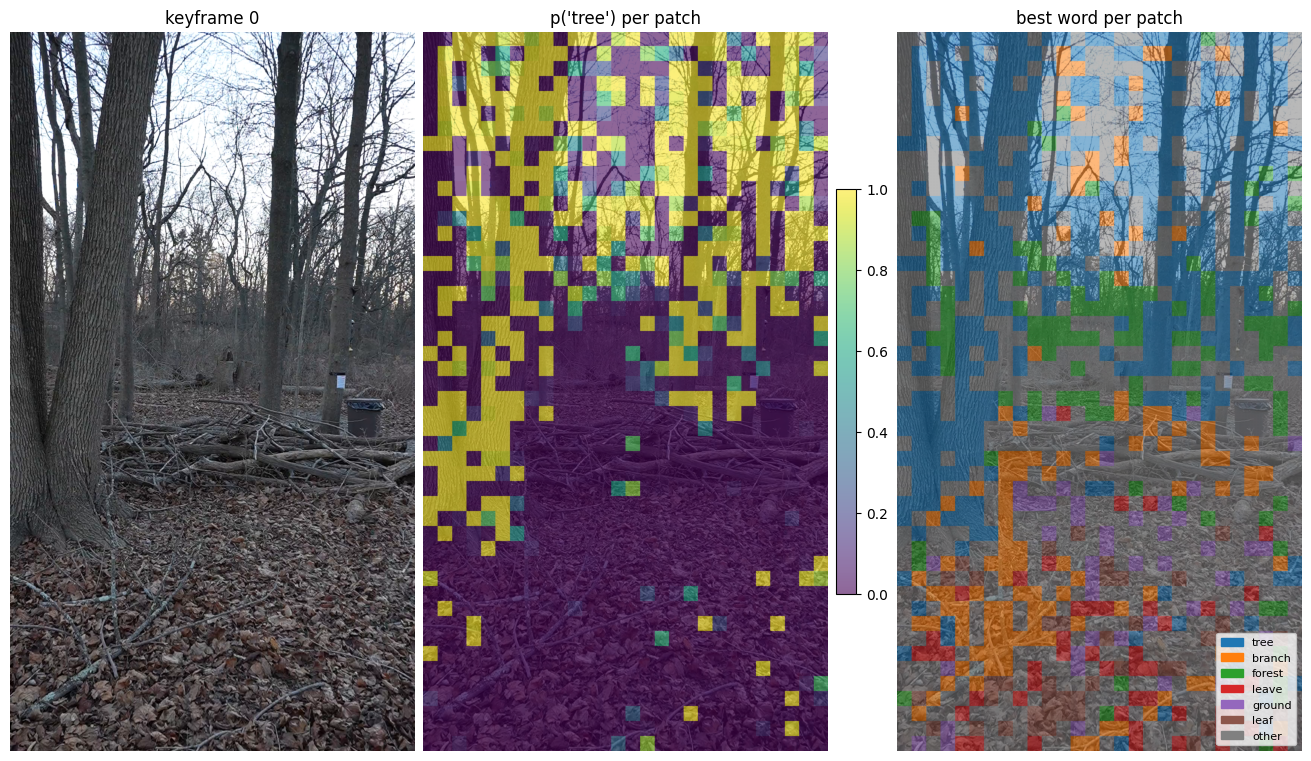

In [4]:
image = np.asarray(read_image(frame_paths(scene.images_dir)[row]))
frame_size = (image.shape[1], image.shape[0])

# Probability of the probe word, upsampled to the frame
probe = "tree"
probe_map = patch_probs[:, words.index(probe)].reshape(height, width)
probe_heat = cv2.resize(probe_map, frame_size, interpolation=cv2.INTER_NEAREST)

# Best word per patch: the six most common keep a color, the rest are "other"
best = patch_probs.argmax(axis=1)
ids, counts = np.unique(best, return_counts=True)
common = ids[np.argsort(counts)[::-1][:6]]
labels = np.full(len(best), len(common))

for k, word_id in enumerate(common):
    labels[best == word_id] = k

label_map = cv2.resize(
    labels.reshape(height, width).astype(np.uint8), frame_size, interpolation=cv2.INTER_NEAREST
)
colors = [*matplotlib.colormaps["tab10"].colors[: len(common)], "grey"]

titles = ["keyframe 0", f"p({probe!r}) per patch", "best word per patch"]
fig, axes = plt.subplots(1, 3, figsize=(13, 7.5), subplot_kw=BARE, layout="constrained")

# The frame under every panel
for ax, title in zip(axes, titles):
    ax.imshow(image)
    ax.set_title(title)

heat = axes[1].imshow(probe_heat, cmap="viridis", alpha=0.6, vmin=0, vmax=1)
fig.colorbar(heat, ax=axes[1], fraction=0.05, pad=0.02, shrink=0.6)
axes[2].imshow(label_map, cmap=ListedColormap(colors), vmin=0, vmax=len(common), alpha=0.55)
legend = [Patch(color=c, label=w) for c, w in zip(colors, [*[words[i] for i in common], "other"])]
axes[2].legend(handles=legend, loc="lower right", fontsize=8)

Single patches are noisy, but the regions make sense: canopy reads as "tree", the brush pile as
"log", sticks as "branch". Lifting averages each vertex over every keyframe that saw it.

## 3. A word on the mesh

The probability of "tree" on every vertex, seen from the side. Grey vertices were never seen:

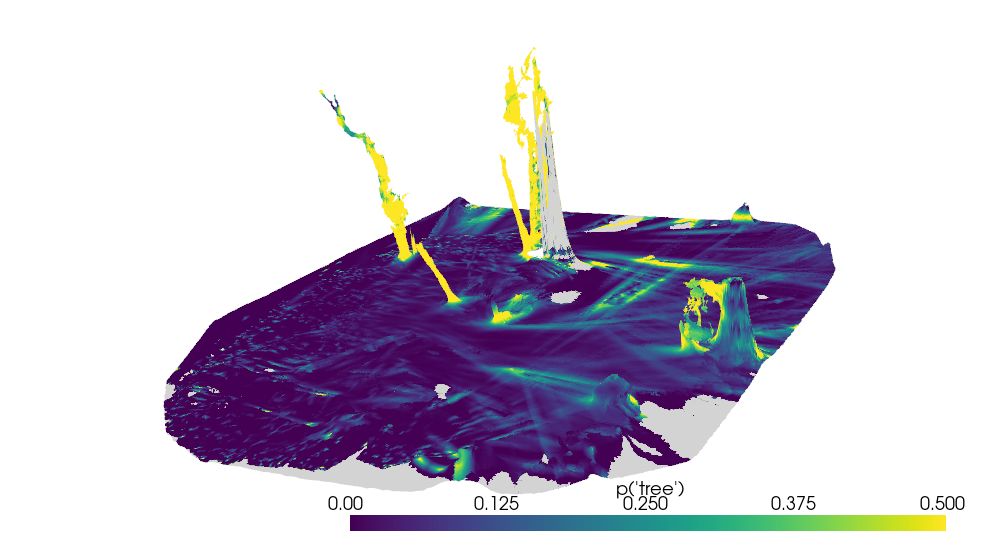

In [5]:
hit = word_ids == words.index(probe)
scores = (word_probs * hit).sum(axis=1)
scores[~observed] = np.nan

mesh = pv.read(scene.outputs["mesh"])
plotter = pv.Plotter(window_size=(1000, 560))
plotter.add_mesh(
    mesh,
    scalars=scores,
    cmap="viridis",
    clim=(0, 0.5),
    nan_color="lightgrey",
    lighting=False,
    scalar_bar_args={"title": f"p({probe!r})"},
)
apply_view(plotter, camera_view(cloud.extrinsics, mesh.points))
plotter.show()

The trunks read as "tree" all over, while the ground stays dark. The color range stops at 0.5 so
surfaces where "tree" is one of several likely words still show.

## In a pipeline run

The semantics stage does all of the above when `ocr_lens` is in its extractors:

```yaml
semantics:
  extractors: [ocr_lens]
```

The scene viewer serves the mesh with a word search and a click probe:

```bash
python -m collab_splats.viewer data/tutorial_scene/vggt_omega --port 8080
```